# Imports

In [4]:
# Imports
import os
import sys
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)
parent_dir
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import time
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator
# Huang 2018 
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}
data =  AS209

dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

# Frank Parameters
N = 1000

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)
### UV coverage
### Analitic functions
import numpy as np
from scipy.special import j0, j1, jn
def synthetic_uvtable_crescent(u, v,
                               sigma_core=0.04,
                               R_rings=[0.4, 0.6, 0.8],
                               width_rings=[0.04, 0.02, 0.05],
                               amp_core=0.2,
                               amp_rings=[0.05, 0.04, 0.03],
                               m_modes=[1, 0, 0],       # asymmetry order for each ring
                               theta0=[np.pi, 0, 0],   # phase angle of each asymmetry component
                               amp_asym=[0.9, 0.3, 0.3],  # relative strength of asymmetry
                               rad_to_arcsec=206265.0,
                               weights=None):
    """
    Generate a synthetic UV table using asymmetric Gaussian-width rings (Fourier-domain model).
    Asymmetries are introduced using low-order azimuthal modes (m-modes).
    """
    baseline = np.sqrt(u**2 + v**2)
    phi_uv = np.arctan2(v, u)  # uv-plane azimuth angle

    # Central Gaussian core (symmetric)
    V_core = amp_core * np.exp(-2 * (np.pi * (sigma_core / rad_to_arcsec) * baseline)**2)

    # Ring components with azimuthal modulation
    V_rings = np.zeros_like(baseline, dtype=complex)

    for A, R, w, m, th0, Aasym in zip(amp_rings, R_rings, width_rings, m_modes, theta0, amp_asym):
        arg = 2 * np.pi * (R / rad_to_arcsec) * baseline
        blur = np.exp(-2 * (np.pi * (w / rad_to_arcsec) * baseline)**2)

        # Axisymmetric ring contribution (m = 0)
        V0 = A * j0(arg) * blur

        # Asymmetric contribution (m-mode modulation)
        Vm = Aasym * A * jn(m, arg) * blur * np.exp(1j * m * (phi_uv - th0))

        V_rings += V0 + Vm

    # Combine core + rings
    vis = V_core + V_rings

    # Default weights = uniform (if none provided)
    if weights is None:
        weights = np.ones_like(u)

    # Determine if noise should be real or complex
    dim0 = 2 if np.iscomplexobj(vis) else 1

    # Add Gaussian noise scaled by weights
    noise = np.random.standard_normal((dim0,) + vis.shape)
    noise *= weights ** -0.5

    vis_noisy = vis + noise[0]
    if np.iscomplexobj(vis):
        vis_noisy += 1j * noise[1]

    # Return UV table dictionary
    uvtable = {
        'u': u,
        'v': v,
        'vis': vis,
        'weights': weights
    }

    return uvtable

frank2d0 = Frank2D(N, rout)
frank2d0.process_vis(uvtable)
u, v = frank2d0.gridded_data['u'], frank2d0.gridded_data['v']
weights = frank2d0.gridded_data['weights']
uvtable_synthetic_full = synthetic_uvtable_crescent(u, v, weights= weights)
vis_syn_full =  uvtable_synthetic_full['vis'].reshape(N, N)
weights_syn_full = uvtable_synthetic_full['weights'].reshape(N, N)
u_syn_full = uvtable_synthetic_full['u'].reshape(N, N)
v_syn_full = uvtable_synthetic_full['v'].reshape(N, N)

zoom = 1

===>  Setting gridded data...


In [23]:
def simular_uv_fisico_realista(u_grid, v_grid, h_min=-4, h_max=4, declinacion=-30, num_baselines=30, concentracion_core=3.0):
    """
    Simula un UV-coverage realista con física de rotación y distribución de antenas
    densa en el centro (core) y dispersa en los bordes.
    
    Args:
        u_grid, v_grid: Matrices de coordenadas.
        h_min, h_max: Horas de observación (ángulo horario).
        declinacion: Declinación de la fuente (grados).
        num_baselines: Número total de pares de antenas.
        concentracion_core (float): Controla la distribución radial.
                                    1.0 = Uniforme (Irreal).
                                    2.0 = Linealmente denso en el centro.
                                    3.0+ = Muy denso en el centro (Tipo ALMA compact).
    """
    
    mask = np.zeros_like(u_grid, dtype=int)
    Ny, Nx = mask.shape
    
    # 1. Configurar Escalas
    u_range = np.max(u_grid) - np.min(u_grid)
    v_range = np.max(v_grid) - np.min(v_grid)
    du = u_range / Nx
    dv = v_range / Ny
    
    # Referencia al valor mínimo para calcular índices
    u_min_val = np.min(u_grid)
    v_min_val = np.min(v_grid)
    
    # 2. Generar Baselines con Distribución Realista (Core denso)
    # Definimos longitudes máxima y mínima
    max_b = np.min([np.max(np.abs(u_grid)), np.max(np.abs(v_grid))]) * 0.6
    min_b = max_b * 0.02 # Baselines muy cortas (shadowing limit aprox)
    
    # --- CAMBIO CLAVE AQUÍ ---
    # Usamos distribución Beta(1, concentracion). 
    # Esto genera números entre 0 y 1, pero sesgados fuertemente hacia el 0.
    distribucion_normalizada = np.random.beta(1, concentracion_core, num_baselines)
    
    # Escalamos al rango real de las baselines
    baselines_lengths = min_b + distribucion_normalizada * (max_b - min_b)
    # -------------------------
    
    baselines_angles = np.random.uniform(0, 2*np.pi, num_baselines)
    
    # Proyección inicial de las antenas (u, v en t=0, d=90)
    Bx = baselines_lengths * np.cos(baselines_angles)
    By = baselines_lengths * np.sin(baselines_angles)
    
    # 3. Física de Rotación (Síntesis de Apertura)
    # Muestreo temporal: Puntos discretos
    num_time_steps = 120 
    H = np.linspace(np.radians(h_min * 15), np.radians(h_max * 15), num_time_steps)
    dec = np.radians(declinacion)
    
    all_u = []
    all_v = []
    
    # Vectorizamos el cálculo para velocidad
    cos_H = np.cos(H)
    sin_H = np.sin(H)
    sin_d = np.sin(dec)
    
    for i in range(num_baselines):
        bx, by = Bx[i], By[i]
        
        # Rotación de Tierra
        u_track = bx * cos_H - by * sin_H
        v_track = (bx * sin_H + by * cos_H) * sin_d
        
        # Guardar (+u, +v) y su simétrico (-u, -v)
        all_u.append(u_track)
        all_v.append(v_track)
        all_u.append(-u_track)
        all_v.append(-v_track)

    pts_u = np.concatenate(all_u)
    pts_v = np.concatenate(all_v)
    
    # 4. Rasterización ("Snapping" a la grilla)
    idx_x = np.round((pts_u - u_min_val) / du).astype(int)
    idx_y = np.round((pts_v - v_min_val) / dv).astype(int)
    
    # Filtrar válidos
    valid = (idx_x >= 0) & (idx_x < Nx) & (idx_y >= 0) & (idx_y < Ny)
    
    # Asignar 1s
    mask[idx_y[valid], idx_x[valid]] = 1
    
    return mask

In [33]:
zoom_int = 1
zoom_vis = 3
size = 20
size_ticks = 14
figsize = (6,6)

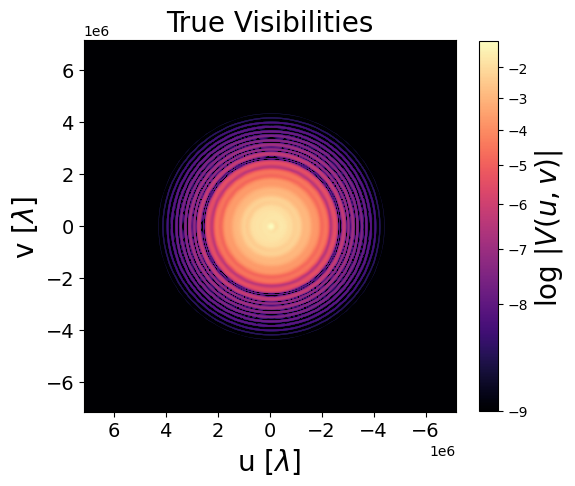

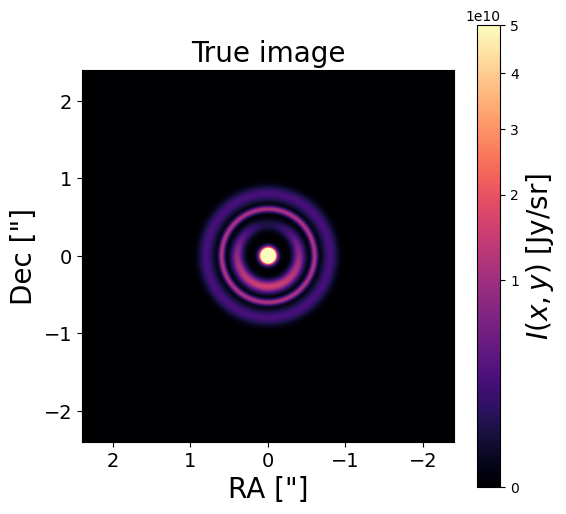

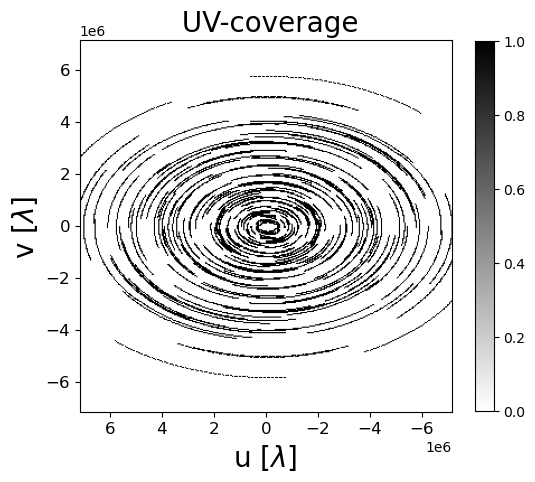

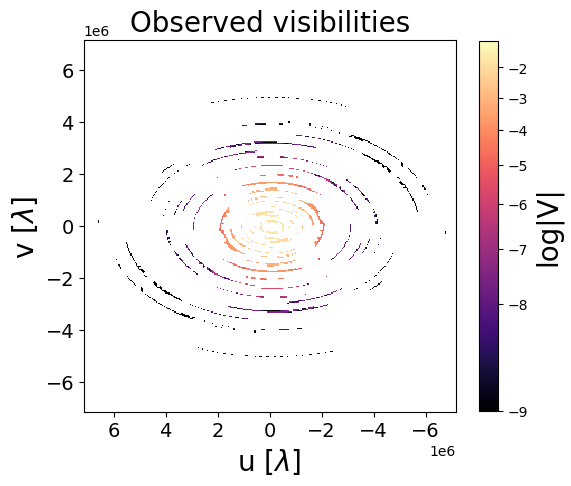

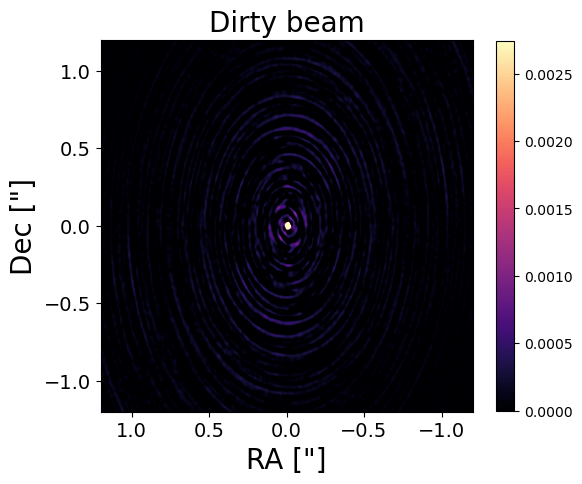

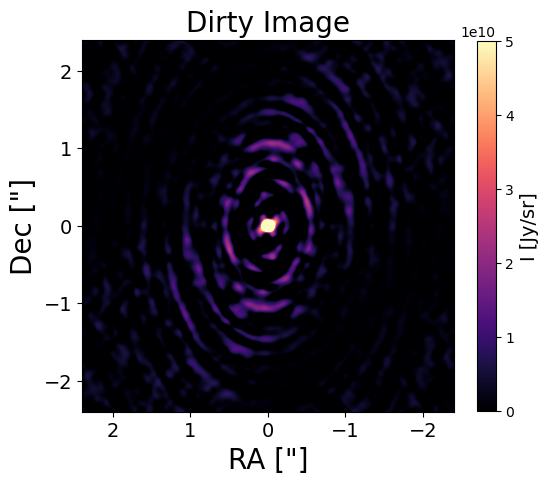

In [37]:
### True Model
plt.figure(figsize=figsize)
norm = colors.PowerNorm(gamma = 0.6, vmax= np.max(np.log(np.abs(vis_syn_full))), vmin = -9)
plt.imshow(np.log(np.abs(vis_syn_full)), cmap='magma', norm=norm, extent=[np.max(u_syn_full), np.min(u_syn_full), np.min(v_syn_full), np.max(v_syn_full)])
cbar = plt.colorbar(shrink=0.8)
cbar.set_label(r'log $|V(u,v)|$ ', size=size)
plt.title('True Visibilities', size=size)
plt.xlim(np.max(u_syn_full)/zoom_vis, np.min(u_syn_full)/zoom_vis)
plt.ylim(np.min(v_syn_full)/zoom_vis, np.max(v_syn_full)/zoom_vis)
plt.xlabel(r'u [$\lambda$] ', size=size)
plt.ylabel(r'v [$\lambda$] ', size=size)
plt.xticks(fontsize=size_ticks)
plt.yticks(fontsize=size_ticks)
plt.show()
dx = frank2d0.dx/rad_to_arcsec
dy = frank2d0.dy/rad_to_arcsec
pixel_area_in_sr = dx * dy
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn_full))).real / pixel_area_in_sr

# True Image
plt.figure(figsize=figsize)
norm = colors.PowerNorm(gamma = 0.5, vmax= 5e10)
plt.imshow(
            I_syn, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )
            
plt.gca().invert_yaxis()
plt.xlim(rout/zoom_int, -rout/zoom_int)
plt.ylim(-rout/zoom_int, rout/zoom_int)
plt.title('True image', size =size)
plt.xlabel('RA ["]', size =size)
plt.ylabel('Dec ["]', size =size)
# increase size of thicks
plt.xticks(size=size_ticks)
plt.yticks(size=size_ticks)
cbar  = plt.colorbar()
cbar.set_label(r'$I(x, y)$ [Jy/sr]', size=size)
## S(u, v)
import numpy as np


N = 256
limit = 500

uv_coverage = simular_uv_fisico_realista(
    u_syn_full, 
    v_syn_full, 
    num_baselines=150,       # Bastantes pares de antenas
    concentracion_core=4.0, # Alto valor = núcleo muy denso (pocos brazos largos)
    h_min=0, h_max=3,      # 6 horas de observación
    declinacion=40
)

# UV coverage plot
plt.figure(figsize=figsize)
plt.imshow(uv_coverage, cmap='gray_r', extent=[np.max(u_syn_full), np.min(u_syn_full), np.min(v_syn_full), np.max(v_syn_full)])
plt.title(" UV-coverage", size = size)
plt.xlim(np.max(u_syn_full)/zoom_vis, np.min(u_syn_full)/zoom_vis)
plt.ylim(np.min(v_syn_full)/zoom_vis, np.max(v_syn_full)/zoom_vis)
plt.xlabel(r'u [$\lambda$] ', size =size)
plt.ylabel(r'v [$\lambda$] ', size =size)
cbar  = plt.colorbar(shrink=0.8)
plt.xticks(size=12)
plt.yticks(size=12)
plt.show()


# dirty visibilities
dirty_vis = vis_syn_full * uv_coverage
norm = colors.PowerNorm(gamma = 0.6, vmax= np.max(np.log(np.abs(vis_syn_full))), vmin = -9)
plt.figure(figsize=figsize)
plt.imshow(np.log(np.abs(dirty_vis)), cmap='magma', norm=norm, extent=[np.max(u_syn_full), np.min(u_syn_full), np.min(v_syn_full), np.max(v_syn_full)])
cbar  = plt.colorbar(shrink=0.8)
cbar.set_label('log|V|', size=size)
plt.title('Observed visibilities', size =size)
plt.xlim(np.max(u_syn_full)/zoom_vis, np.min(u_syn_full)/zoom_vis)
plt.ylim(np.min(v_syn_full)/zoom_vis, np.max(v_syn_full)/zoom_vis)
plt.xlabel(r'u [$\lambda$] ', size =size)
plt.ylabel(r'v [$\lambda$] ', size =size)
plt.xticks(size=size_ticks)
plt.yticks(size=size_ticks)
plt.show()


# dirty beam
I_dirty_beam = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(uv_coverage))).real
norm = colors.PowerNorm(gamma = 1, vmin =0, vmax= np.max(I_dirty_beam)/5)
plt.figure(figsize=figsize)
plt.imshow(
            I_dirty_beam, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )
plt.gca().invert_yaxis()
plt.xlim(rout/2, -rout/2)
plt.ylim(-rout/2, rout/2)
plt.title('Dirty beam', size =size)
plt.xlabel('RA ["]', size =size)
plt.ylabel('Dec ["]', size =size)
plt.xticks(size=size_ticks)
plt.yticks(size=size_ticks)
cbar  = plt.colorbar(shrink=0.8)
cbar.set_label('', size=size)

### dirty image
I_dirty_image = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(dirty_vis))).real / pixel_area_in_sr
norm = colors.PowerNorm(gamma = 1, vmax= 5e10, vmin =0)
plt.figure(figsize=figsize)

plt.imshow(
            I_dirty_image, 
            extent=[frank2d0.Rmax, -frank2d0.Rmax, -frank2d0.Rmax, frank2d0.Rmax],
            norm=norm, 
            cmap = 'magma'
            )
plt.gca().invert_yaxis()
plt.xlim(rout/zoom_int, -rout/zoom_int)
plt.ylim(-rout/zoom_int, rout/zoom_int)
plt.title('Dirty Image', size =size)
plt.xlabel('RA ["]', size =size)
plt.ylabel('Dec ["]', size =size)
plt.xticks(size=size_ticks)
plt.yticks(size=size_ticks)
cbar  = plt.colorbar(shrink=0.8)
cbar.set_label('I [Jy/sr]', size=14)


In [30]:
# AS209 UV-coverage
uvtable_synthetic = synthetic_uvtable_gaussian_blob(uvtable['u'], uvtable['v'], weights=uvtable['weights'])
u_syn, v_syn = uvtable_synthetic['u'], uvtable_synthetic['v']
vis_syn = uvtable_synthetic['vis']
weights_syn = uvtable_synthetic['weights']
#np.savez_compressed("uvtable_nonsym_disc_blob_noisy.npz", **uvtable_synthetic)
N = 300
rout = 1*2
frank2d = Frank2D(N, rout, geom)
frank2d.process_vis(uvtable_synthetic)
uvtable_synthetic_gridded = frank2d.gridded_data
u_syn = uvtable_synthetic_gridded['u'].reshape(N, N)
v_syn = uvtable_synthetic_gridded['v'].reshape(N, N)
vis_syn = uvtable_synthetic_gridded['vis'].reshape(N, N)
weights_syn = uvtable_synthetic_gridded['weights'].reshape(N, N)
plt.imshow(np.log(np.abs(vis_syn)),
             extent=[u_syn.max(), u_syn.min(), v_syn.min(), v_syn.max()],
             cmap = "magma", 
             vmin=-10, vmax=-2)
plt.colorbar(label='log|V| [Jy]')
plt.title('Synthetic visibilities gridded by Frank2D', size=10)
plt.xlabel('u [λ]')
plt.ylabel('v [λ]')
params_1 = {'m' : -2, 'c' : 1e8, 'l' : 7e4}
params_2 = {'m' : -1.8, 'c' : 1e9, 'l' : 7e4}
params_3 = {'m' : -1.5, 'c' : 1e9, 'l' : 7e4}
best = {'m': -2.0109174914721892, 'c': 10930405059.44571, 'l': 2633846.3020098973}
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u_syn.flatten(), v_syn.flatten()
Vis = vis_syn.flatten()
Weights = weights_syn.flatten()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
logx = np.log10(binned_vis.uv)
logy = np.log10(np.abs(binned_vis.V)**2)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
logx2 = np.log10(binned_vis2.uv)
logy2 = np.log10(np.abs(binned_vis2.V)**2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)


lgx = np.log10(np.geomspace(np.sort(baselines)[1], baselines.max(), 1000))

lgy1 = linear_power_spectrum(lgx, params_1['m'], params_1['c'])
lgy2 = linear_power_spectrum(lgx, params_2['m'], params_2['c'])
lgy3 = linear_power_spectrum(lgx, params_3['m'], params_3['c'])
#lgy_best = linear_power_spectrum(lgx, best['m'], best['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

plt.figure(figsize=(9, 4))
plt.plot(logx, logy, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(logx2, logy2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

#plt.plot(lgx, lgy1, ls='-', color= 'r', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_1['m'], np.log10(params_1['c'])))
plt.plot(lgx, lgy2, ls='-', color= 'blue', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_2['m'], np.log10(params_2['c'])))
#plt.plot(lgx, lgy3, ls='-', color= 'green', label='MAP, m={:.2f}, log(c)={:.2f}'.format(params_3['m'], np.log10(params_3['c'])))
#plt.plot(lgx, lgy_best, ls='--', color= 'orange', label='Best fit, m={:.2f}, log(c)={:.2f}'.format(best['m'], np.log10(best['c'])))

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.legend(loc = 'best', fontsize = 'x-small')
plt.title("Power spectrum")
plt.ylim(-13, 2)
plt.xlim(5, 7)
plt.show()
dx = frank2d.dx/rad_to_arcsec
dy = frank2d.dy/rad_to_arcsec
I_syn = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(vis_syn))).real/(dx * dy)
import matplotlib.colors as colors
norm = colors.PowerNorm(gamma = 1, vmin = 0, vmax = 1e10)

plt.imshow(
            I_syn, 
            extent=[frank2d.Rmax, -frank2d.Rmax, -frank2d.Rmax, frank2d.Rmax],
            norm=norm, 
            cmap = 'magma'
            )

plt.gca().invert_yaxis()
plt.xlim(rout, -rout)
plt.ylim(-rout, rout)
#plt.title('Synthetic model of a non axisymmetric disk')
plt.xlabel('RA ["]')
plt.ylabel('Dec ["]')
plt.colorbar(label='I [Jy/sr]')
import numpy as np
import matplotlib.pyplot as plt

N = 256
x = np.linspace(-10, 10, N)
y = np.linspace(-10, 10, N)
X, Y = np.meshgrid(x, y)

sigma = 2.0
gaussian_spatial = np.exp(-(X**2 + Y**2) / (2 * sigma**2))

gaussian_shifted = np.fft.ifftshift(gaussian_spatial)
fft_complex = np.fft.fft2(gaussian_shifted)
fft_centered = np.fft.fftshift(fft_complex)

amplitude = np.log(1 + np.abs(fft_centered))
phase = np.angle(fft_centered)

threshold = 1e-10
phase[np.abs(fft_centered) < threshold] = 0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(gaussian_spatial, cmap='magma', extent=[-10, 10, -10, 10], origin='lower')
axes[0].set_title('Spatial Gaussian')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(amplitude, cmap='inferno', extent=[-N/2, N/2, -N/2, N/2], origin='lower')
axes[1].set_title('FFT Amplitude (Log)')
axes[1].set_xlabel('u')
axes[1].set_ylabel('v')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

im3 = axes[2].imshow(phase, cmap='magma', extent=[-N/2, N/2, -N/2, N/2], origin='lower', vmin=-np.pi, vmax=np.pi)
axes[2].set_title('FFT Phase')
axes[2].set_xlabel('u')
axes[2].set_ylabel('v')
cbar3 = plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
cbar3.set_ticks([-np.pi, 0, np.pi])
cbar3.set_ticklabels(['-π', '0', 'π'])

plt.tight_layout()
plt.show()

NameError: name 'synthetic_uvtable_gaussian_blob' is not defined